In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_df = pd.read_excel('/home/dell/Documents/project_3/FAOSTAT_data.xlsx')

In [3]:
data_df.shape

(224647, 15)

In [4]:
data_df.columns


Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224647 entries, 0 to 224646
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Domain Code       224647 non-null  object 
 1   Domain            224647 non-null  object 
 2   Area Code (M49)   224647 non-null  int64  
 3   Area              224647 non-null  object 
 4   Element Code      224647 non-null  int64  
 5   Element           224647 non-null  object 
 6   Item Code (CPC)   224642 non-null  object 
 7   Item              224647 non-null  object 
 8   Year Code         224647 non-null  int64  
 9   Year              224647 non-null  int64  
 10  Unit              224645 non-null  object 
 11  Value             218130 non-null  float64
 12  Flag              224643 non-null  object 
 13  Flag Description  224634 non-null  object 
 14  Note              5098 non-null    object 
dtypes: float64(1), int64(4), object(10)
memory usage: 25.7+ MB


In [6]:
data_df.head(2)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,2019,ha,29203.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,2019,kg/ha,1308.3,A,Official figure,NaN


In [7]:
data_df.Value.value_counts()

Value
0.0         6813
10.0         411
20.0         386
1000.0       385
100.0        361
            ... 
1185.6         1
138648.0       1
143636.0       1
142547.0       1
904300.0       1
Name: count, Length: 125184, dtype: int64

In [8]:
data_df['Element'].value_counts()

Element
Production                       86382
Yield                            51566
Area harvested                   50309
Producing Animals/Slaughtered    18059
Stocks                            8809
Yield/Carcass Weight              6307
Milk Animals                      2146
Laying                            1069
Name: count, dtype: int64

In [9]:
harvested_area = data_df[(data_df['Element'] == 'Area harvested') & (data_df['Unit'] == 'ha')]
harvested_area.head(2)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,2019,ha,29203.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,2020,ha,22134.0,A,Official figure,NaN


In [10]:
keep_columns = ['Area', 'Item', 'Year', 'Value']
area_clean = harvested_area[keep_columns]

# Rename the generic 'Value' column to a specific header name
area_clean = area_clean.rename(columns={'Value': 'Area_Harvested_ha'})

In [11]:
area_clean

,Area,Item,Year,Area_Harvested_ha
0,Afghanistan,"Almonds, in shell",2019,29203.0
3,Afghanistan,"Almonds, in shell",2020,22134.0
6,Afghanistan,"Almonds, in shell",2021,36862.0
9,Afghanistan,"Almonds, in shell",2022,36462.0
12,Afghanistan,"Almonds, in shell",2023,37000.0
...,...,...,...,...
224619,Zimbabwe,Wheat,2019,24186.0
224622,Zimbabwe,Wheat,2020,44466.0
224625,Zimbabwe,Wheat,2021,66434.0
224628,Zimbabwe,Wheat,2022,48504.0


In [12]:
yield_rows = data_df[(data_df['Element'] == 'Yield') & (data_df['Unit'] == 'kg/ha')]
yield_clean = yield_rows[keep_columns]

# Rename 'Value' to reflect crop yield
yield_clean = yield_clean.rename(columns={'Value': 'Yield_kg_ha'})

In [13]:
yield_clean

,Area,Item,Year,Yield_kg_ha
1,Afghanistan,"Almonds, in shell",2019,1308.3
4,Afghanistan,"Almonds, in shell",2020,1775.9
7,Afghanistan,"Almonds, in shell",2021,1743.2
10,Afghanistan,"Almonds, in shell",2022,1742.0
13,Afghanistan,"Almonds, in shell",2023,1810.8
...,...,...,...,...
224620,Zimbabwe,Wheat,2019,3914.9
224623,Zimbabwe,Wheat,2020,4779.6
224626,Zimbabwe,Wheat,2021,5075.9
224629,Zimbabwe,Wheat,2022,5154.2


In [14]:
prod_rows = data_df[(data_df['Element'] == 'Production') & (data_df['Unit'] == 't')]
prod_clean = prod_rows[keep_columns]

# Rename 'Value' to reflect production tons
prod_clean = prod_clean.rename(columns={'Value': 'Production_tons'})

In [15]:
prod_clean

,Area,Item,Year,Production_tons
2,Afghanistan,"Almonds, in shell",2019,38205.00
5,Afghanistan,"Almonds, in shell",2020,39307.00
8,Afghanistan,"Almonds, in shell",2021,64256.00
11,Afghanistan,"Almonds, in shell",2022,63515.00
14,Afghanistan,"Almonds, in shell",2023,67000.00
...,...,...,...,...
224642,Zimbabwe,"Whole milk, evaporated",2019,5010.21
224643,Zimbabwe,"Whole milk, evaporated",2020,4795.70
224644,Zimbabwe,"Whole milk, evaporated",2021,4921.05
224645,Zimbabwe,"Whole milk, evaporated",2022,4966.37


In [16]:
step1_merge = pd.merge(area_clean, yield_clean, on=['Area', 'Item', 'Year'], how='outer')

In [17]:
step1_merge

,Area,Item,Year,Area_Harvested_ha,Yield_kg_ha
0,Afghanistan,"Almonds, in shell",2019,29203.0,1308.3
1,Afghanistan,"Almonds, in shell",2020,22134.0,1775.9
2,Afghanistan,"Almonds, in shell",2021,36862.0,1743.2
3,Afghanistan,"Almonds, in shell",2022,36462.0,1742.0
4,Afghanistan,"Almonds, in shell",2023,37000.0,1810.8
...,...,...,...,...,...
50304,Zimbabwe,Wheat,2019,24186.0,3914.9
50305,Zimbabwe,Wheat,2020,44466.0,4779.6
50306,Zimbabwe,Wheat,2021,66434.0,5075.9
50307,Zimbabwe,Wheat,2022,48504.0,5154.2


In [18]:
final_table = pd.merge(step1_merge, prod_clean, on=['Area', 'Item', 'Year'], how='outer')

In [19]:
final_table

,Area,Item,Year,Area_Harvested_ha,Yield_kg_ha,Production_tons
0,Afghanistan,"Almonds, in shell",2019,29203.0,1308.3,38205.00
1,Afghanistan,"Almonds, in shell",2020,22134.0,1775.9,39307.00
2,Afghanistan,"Almonds, in shell",2021,36862.0,1743.2,64256.00
3,Afghanistan,"Almonds, in shell",2022,36462.0,1742.0,63515.00
4,Afghanistan,"Almonds, in shell",2023,37000.0,1810.8,67000.00
...,...,...,...,...,...,...
85421,Zimbabwe,"Whole milk, evaporated",2019,NaN,NaN,5010.21
85422,Zimbabwe,"Whole milk, evaporated",2020,NaN,NaN,4795.70
85423,Zimbabwe,"Whole milk, evaporated",2021,NaN,NaN,4921.05
85424,Zimbabwe,"Whole milk, evaporated",2022,NaN,NaN,4966.37


In [20]:
final_table.Item.nunique()

258

In [ ]:
# Analyze Crop Distribution

In [21]:
crop_dist = final_table.groupby('Item').agg(
    Total_Area_ha=('Area_Harvested_ha', 'sum'),
    Regions_Count=('Area', 'nunique'),
    Total_Production_tons=('Production_tons', 'sum')
).reset_index()

In [22]:
crop_dist

,Item,Total_Area_ha,Regions_Count,Total_Production_tons
0,"Abaca, manila hemp, raw",900401.0,7,5.435462e+05
1,"Agave fibres, raw, n.e.c.",290250.0,8,2.003663e+05
2,"Almonds, in shell",11319919.0,67,1.932362e+07
3,"Anise, badian, coriander, cumin, caraway, fenn...",11521768.0,36,1.333680e+07
4,Apples,33297318.0,96,6.943587e+08
...,...,...,...,...
253,"Whole milk, evaporated",0.0,62,1.223549e+07
254,Wine,0.0,80,1.158211e+08
255,Yams,50819800.0,60,4.237027e+08
256,Yautia,158871.0,15,1.945518e+06


In [23]:
most_cultivated = crop_dist.sort_values(by='Total_Area_ha', ascending=False).head(10)
most_cultivated

,Item,Total_Area_ha,Regions_Count,Total_Production_tons
113,Maize (corn),1.225409e+09,172,7.261320e+09
248,Wheat,1.207876e+09,127,4.587546e+09
207,Rice,9.782713e+08,144,4.967913e+09
225,Soya beans,6.990434e+08,118,1.883536e+09
12,Barley,2.460535e+08,108,7.722496e+08
193,Rape or colza seed,2.236346e+08,70,4.689539e+08
222,Sorghum,2.046546e+08,128,3.062838e+08
13,"Beans, dry",1.849894e+08,113,1.446521e+08
91,"Groundnuts, excluding shelled",1.780531e+08,114,3.591810e+08
211,"Seed cotton, unginned",1.773529e+08,100,4.766751e+08


/tmp/ipykernel_6132/2562476208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_cultivated, x='Total_Area_ha', y='Item', palette='viridis')
/tmp/ipykernel_6132/2562476208.py:6: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dell/Documents/project_3/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


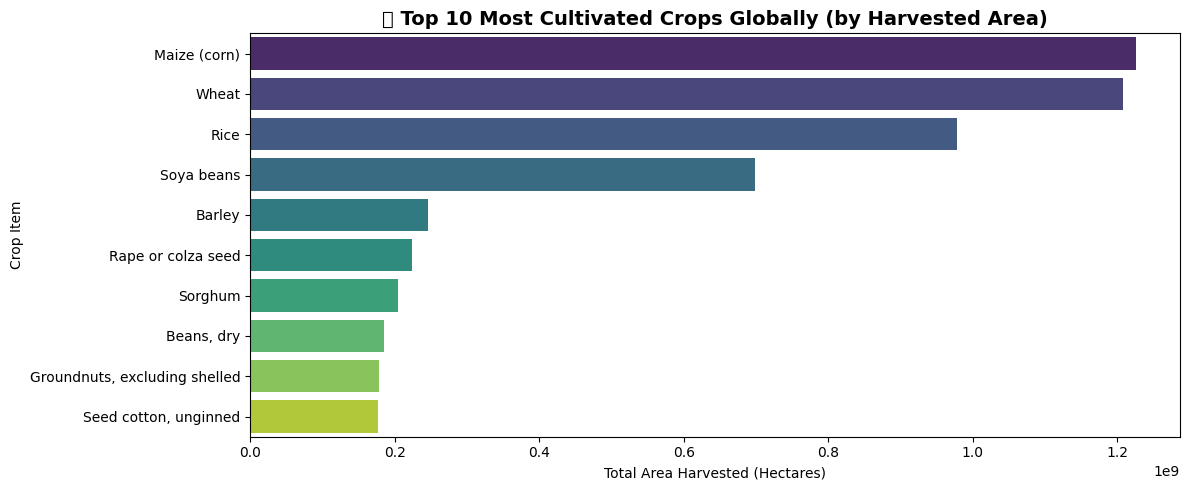

In [24]:
plt.figure(figsize=(12, 5))
sns.barplot(data=most_cultivated, x='Total_Area_ha', y='Item', palette='viridis')
plt.title('🌍 Top 10 Most Cultivated Crops Globally (by Harvested Area)', fontsize=14, fontweight='bold')
plt.xlabel('Total Area Harvested (Hectares)')
plt.ylabel('Crop Item')
plt.tight_layout()
plt.show()

In [25]:
least_cultivated = crop_dist[crop_dist['Total_Area_ha'] > 0].sort_values(by='Total_Area_ha', ascending=True).head(10)
least_cultivated

,Item,Total_Area_ha,Regions_Count,Total_Production_tons
97,Jojoba seeds,1531.0,1,723.88
177,"Peppermint, spearmint",11918.0,9,246787.88
46,Chicory roots,14990.0,13,153909.31
111,Locust beans (carobs),74826.0,11,262693.28
189,"Pyrethrum, dried flowers",87749.0,10,34024.94
85,Gooseberries,93231.0,9,448313.79
60,Cranberries,116281.0,8,2675091.27
162,Other pome fruits,120000.0,24,644602.00
192,"Ramie, raw or retted",151501.0,8,290362.44
256,Yautia,158871.0,15,1945517.68


/tmp/ipykernel_6132/2105952091.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=least_cultivated, x='Total_Area_ha', y='Item', palette='viridis')
/tmp/ipykernel_6132/2105952091.py:6: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dell/Documents/project_3/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


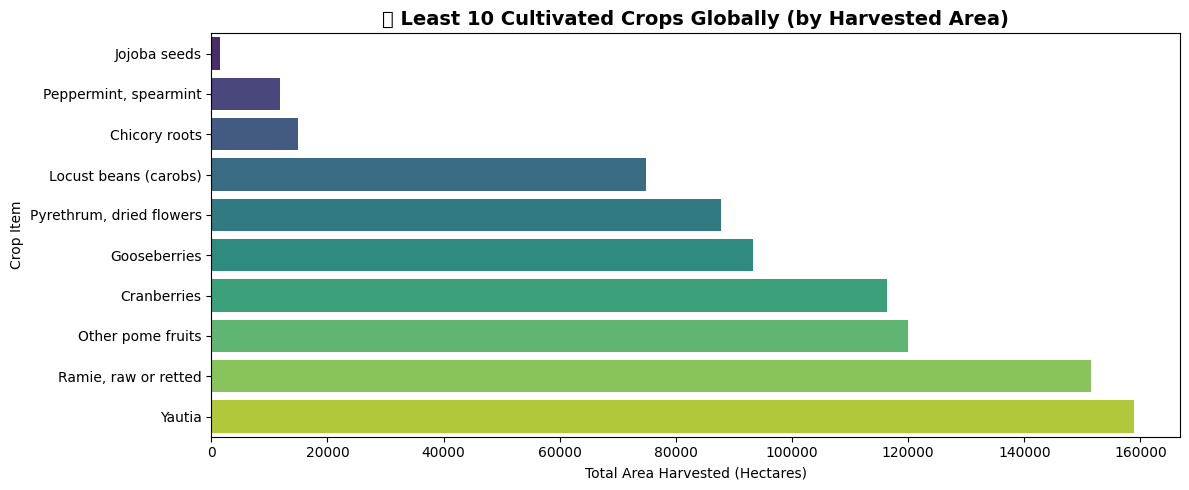

In [26]:
plt.figure(figsize=(12, 5))
sns.barplot(data=least_cultivated, x='Total_Area_ha', y='Item', palette='viridis')
plt.title('🌍 Least 10 Cultivated Crops Globally (by Harvested Area)', fontsize=14, fontweight='bold')
plt.xlabel('Total Area Harvested (Hectares)')
plt.ylabel('Crop Item')
plt.tight_layout()
plt.show()

In [27]:
# 1. Total Country Activity (Top 10 Regions by Land Use and Production Volume)
regional_activity = final_table.groupby('Area').agg(
    Total_Area_ha=('Area_Harvested_ha', 'sum'),
    Total_Prod_tons=('Production_tons', 'sum')
).sort_values(by='Total_Prod_tons', ascending=False).head(15).reset_index()

/tmp/ipykernel_6132/1670540549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_activity, x='Total_Prod_tons', y='Area', palette='magma')
/tmp/ipykernel_6132/1670540549.py:6: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dell/Documents/project_3/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


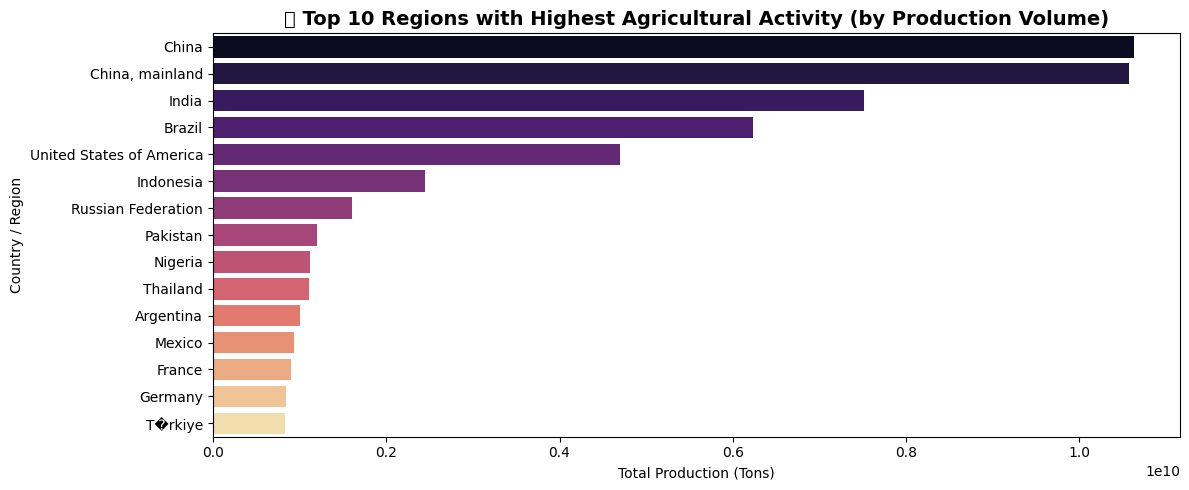

In [28]:
plt.figure(figsize=(12, 5))
sns.barplot(data=regional_activity, x='Total_Prod_tons', y='Area', palette='magma')
plt.title('🏆 Top 10 Regions with Highest Agricultural Activity (by Production Volume)', fontsize=14, fontweight='bold')
plt.xlabel('Total Production (Tons)')
plt.ylabel('Country / Region')
plt.tight_layout()
plt.show()

In [29]:
regional_crop_share = final_table.groupby(['Area', 'Item'])['Area_Harvested_ha'].sum().reset_index()
regional_crop_share

,Area,Item,Area_Harvested_ha
0,Afghanistan,"Almonds, in shell",161661.0
1,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",127050.0
2,Afghanistan,Apples,144828.0
3,Afghanistan,Apricots,111021.0
4,Afghanistan,Barley,352394.0
...,...,...,...
17994,Zimbabwe,Wheat,249468.0
17995,Zimbabwe,Whole milk powder,0.0
17996,Zimbabwe,"Whole milk, condensed",0.0
17997,Zimbabwe,"Whole milk, evaporated",0.0


In [30]:
idx_max = regional_crop_share.groupby('Area')['Area_Harvested_ha'].idxmax()
regional_specialization = regional_crop_share.loc[idx_max].sort_values(by='Area_Harvested_ha', ascending=False)

print("--- 🗺️ GEOGRAPHICAL SPECIALIZATION HIGHLIGHTS ---")
print("Top 5 regions and the specific crop that dominates their agricultural land footprint:")
for idx, row in regional_specialization.head(5).iterrows():
    print(f"{row['Area']}: Most land is dedicated to '{row['Item']}' ({row['Area_Harvested_ha']:,.0f} ha)")

--- 🗺️ GEOGRAPHICAL SPECIALIZATION HIGHLIGHTS ---
Top 5 regions and the specific crop that dominates their agricultural land footprint:
India: Most land is dedicated to 'Rice' (231,370,000 ha)
China: Most land is dedicated to 'Maize (corn)' (213,319,730 ha)
China, mainland: Most land is dedicated to 'Maize (corn)' (213,153,000 ha)
Brazil: Most land is dedicated to 'Soya beans' (197,711,572 ha)
United States of America: Most land is dedicated to 'Maize (corn)' (167,483,400 ha)


In [31]:
# Temporal Analysis
# Yearly Trends: Analyze the Year column to detect trends in Area harvested, Yield, and Production over time.
# Growth Analysis: Investigate if certain crops or regions show increasing or decreasing trends in yield or production.


In [32]:
yearly_summary = final_table.groupby('Year').agg({
    'Production_tons': 'sum',
    'Area_Harvested_ha': 'sum',
    'Yield_kg_ha': 'mean'
}).reset_index()

In [33]:
yearly_summary

,Year,Production_tons,Area_Harvested_ha,Yield_kg_ha
0,2019,1.379919e+10,1.597569e+09,12459.117649
1,2020,1.384264e+10,1.627753e+09,12519.056381
2,2021,1.411650e+10,1.649768e+09,12631.844932
3,2022,1.425165e+10,1.657080e+09,12625.338156
4,2023,1.346923e+10,1.672363e+09,12682.508312


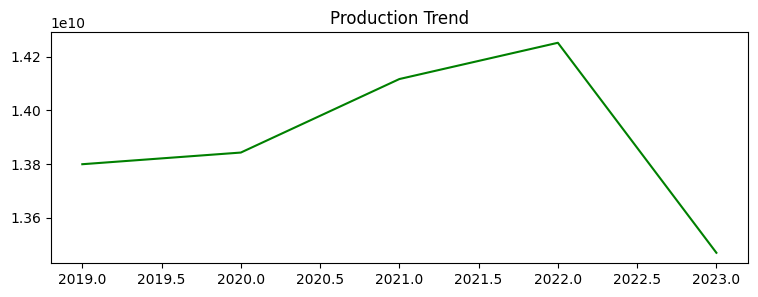

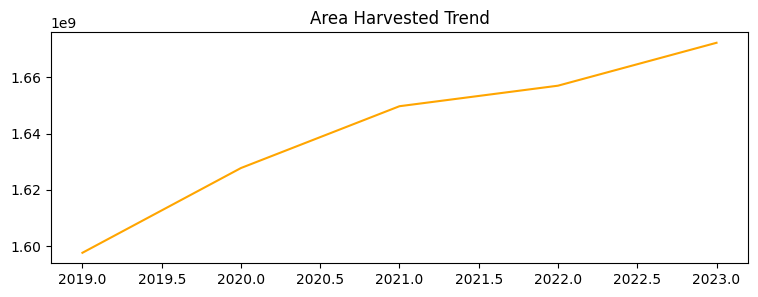

In [34]:
# Group by Year and sum up the numbers
yearly_totals = final_table.groupby('Year').sum().reset_index()

# Plot Production
plt.figure(figsize=(9, 3))
plt.plot(yearly_totals['Year'], yearly_totals['Production_tons'], color='green')
plt.title('Production Trend')
plt.show()

# Plot Area
plt.figure(figsize=(9, 3))
plt.plot(yearly_totals['Year'], yearly_totals['Area_Harvested_ha'], color='orange')
plt.title('Area Harvested Trend')
plt.show()

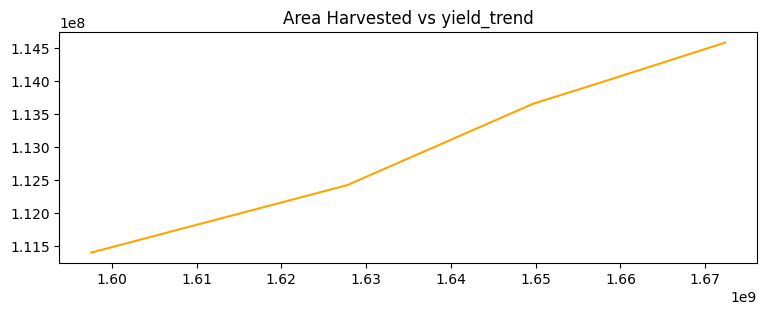

In [35]:
# Plot Area
plt.figure(figsize=(9, 3))
plt.plot(yearly_totals['Area_Harvested_ha'], yearly_totals['Yield_kg_ha'], color='orange')
plt.title('Area Harvested vs yield_trend')
plt.show()

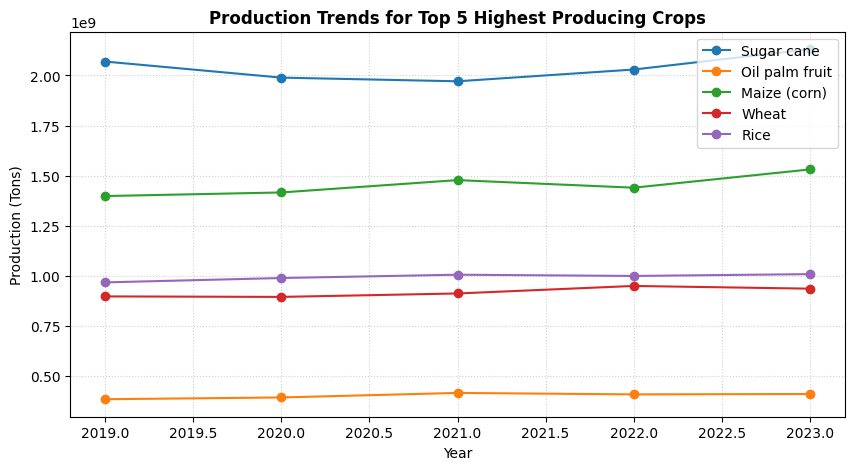

In [36]:

# 1. Get the list of your top 5 crops (using your exact code snippet logic)
top_5_names = final_table.groupby('Item')['Production_tons'].mean().sort_values(ascending=False).head(5).index

# 2. Group by both Crop and Year to get production totals over time
crop_timeline = final_table.groupby(['Item', 'Year'])['Production_tons'].sum().reset_index()

# 3. Plot a line for each of those top 5 crops
plt.figure(figsize=(10, 5))

for crop in top_5_names:
    # Filter the timeline data for just this specific crop
    crop_data = crop_timeline[crop_timeline['Item'] == crop]
    
    # Draw the line
    plt.plot(crop_data['Year'], crop_data['Production_tons'], label=crop, marker='o')

# 4. Add simple labels and legend
plt.title('Production Trends for Top 5 Highest Producing Crops', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Production (Tons)')
plt.legend() # Displays the crop names clearly matching their line colors
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
# Environmental Relationships


In [37]:
correlation_score = final_table['Area_Harvested_ha'].corr(final_table['Yield_kg_ha'])
correlation_score

np.float64(-0.026552169833883876)

In [43]:
plot_df = final_table[['Year', 'Area_Harvested_ha', 'Yield_kg_ha']].copy()

In [44]:
plot_df['Area (Scaled)'] = (plot_df['Area_Harvested_ha'] - plot_df['Area_Harvested_ha'].min()) / (plot_df['Area_Harvested_ha'].max() - plot_df['Area_Harvested_ha'].min())

In [45]:
plot_df['Yield (Scaled)'] = (plot_df['Yield_kg_ha'] - plot_df['Yield_kg_ha'].min()) / (plot_df['Yield_kg_ha'].max() - plot_df['Yield_kg_ha'].min())

In [52]:
melted_df = pd.melt(
    plot_df, 
    id_vars=['Year'], 
    value_vars=['Area (Scaled)', 'Yield (Scaled)'],
    var_name='Metric', 
    value_name='Scaled Value'
)

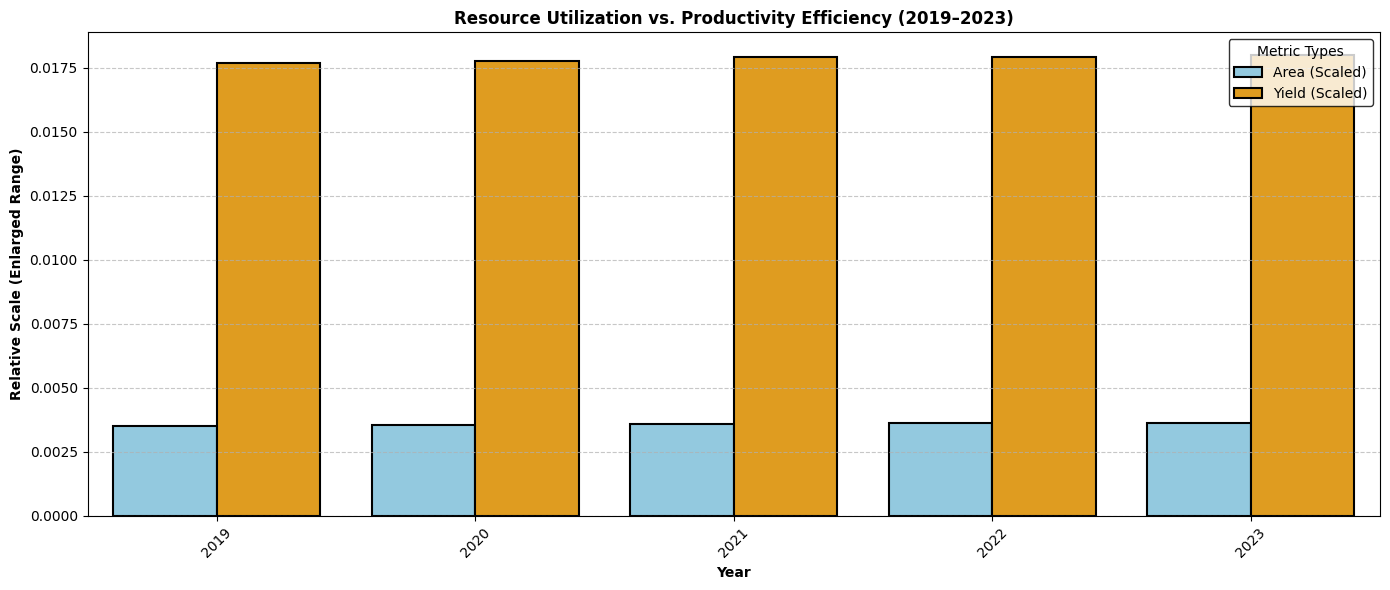

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plotting as a grouped bar chart using the exact same structure
sns.barplot(
    data=melted_df, 
    x='Year', 
    y='Scaled Value', 
    hue='Metric', 
    palette=['skyblue', 'orange'],
    edgecolor='black',              # Sharp black perimeters for the bars
    linewidth=1.5,                  # Visible bar outlines
    errorbar=None                   # Hides error lines to keep the bars completely clean
)

# 🔍 THE ZOOM BOUNDARY: Keeps the visual comparison strictly between 0.0 and 0.5

plt.title('Resource Utilization vs. Productivity Efficiency (2019–2023)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Relative Scale (Enlarged Range)', fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Metric Types', frameon=True, edgecolor='black') 
plt.grid(axis='y', linestyle='--', alpha=0.7)                     

plt.tight_layout()
plt.show()

In [55]:
# Input-Output Relationships


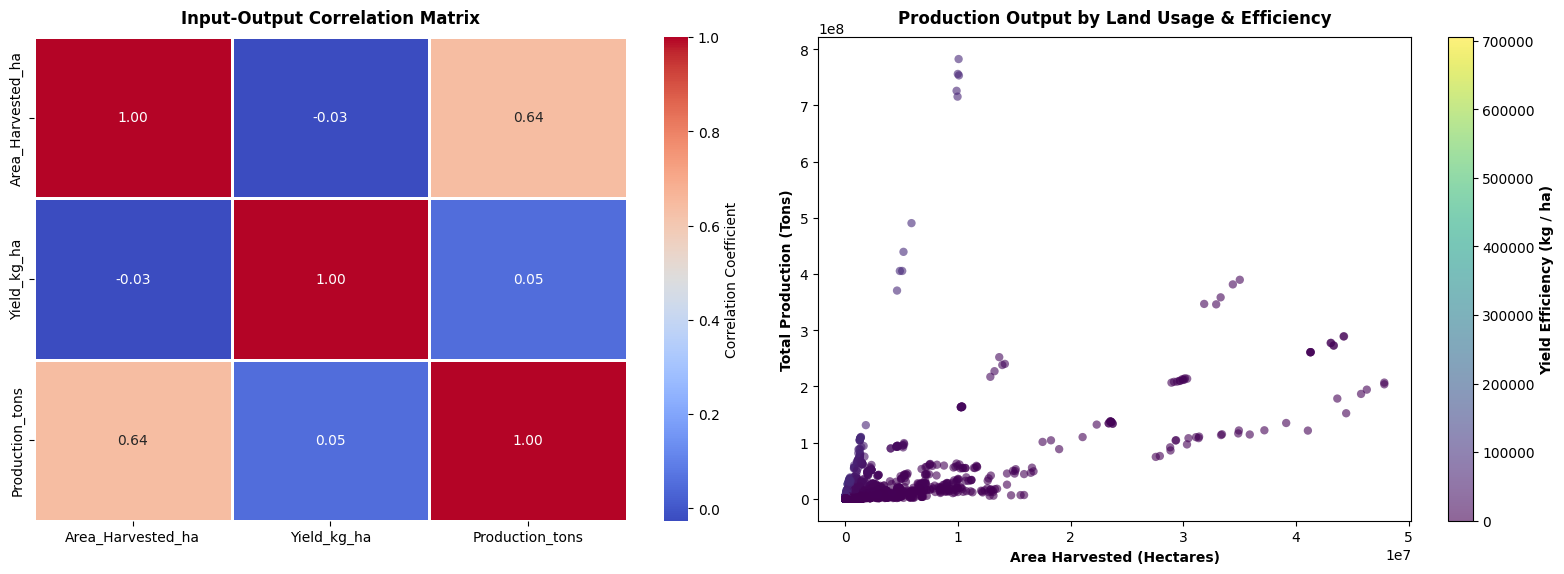

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate the correlation matrix (using Production_tons)
correlation_matrix = final_table[['Area_Harvested_ha', 'Yield_kg_ha', 'Production_tons']].corr()

# Step 2: Set up a 1-row, 2-column layout for a comprehensive analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Correlation Heatmap ---
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=1, 
    ax=ax1,
    cbar_kws={'label': 'Correlation Coefficient'}
)
ax1.set_title('Input-Output Correlation Matrix', fontsize=12, fontweight='bold', pad=10)

# --- PLOT 2: Scatter Plot (Area vs Production shaded by Yield) ---
# FIXED: Updated y='Production_t' to y='Production_tons' to match your dataframe
scatter = ax2.scatter(
    data=final_table,
    x='Area_Harvested_ha',
    y='Production_tons',
    c='Yield_kg_ha',
    cmap='viridis',
    alpha=0.6,
    edgecolors='none'
)
ax2.set_title('Production Output by Land Usage & Efficiency', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Area Harvested (Hectares)', fontweight='bold')
ax2.set_ylabel('Total Production (Tons)', fontweight='bold')

# Add a colorbar to track Yield efficiency on the scatter plot
cbar = fig.colorbar(scatter, ax=ax2)
cbar.set_label('Yield Efficiency (kg / ha)', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Comparative Analysis
# Across Crops: Compare yields (Yield) of different crops (Item) to identify high-yield vs. low-yield crops.
# Across Regions: Compare production (Production) across different areas (Area) to find highly productive regions.


/tmp/ipykernel_6132/1836170162.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_6132/1836170162.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


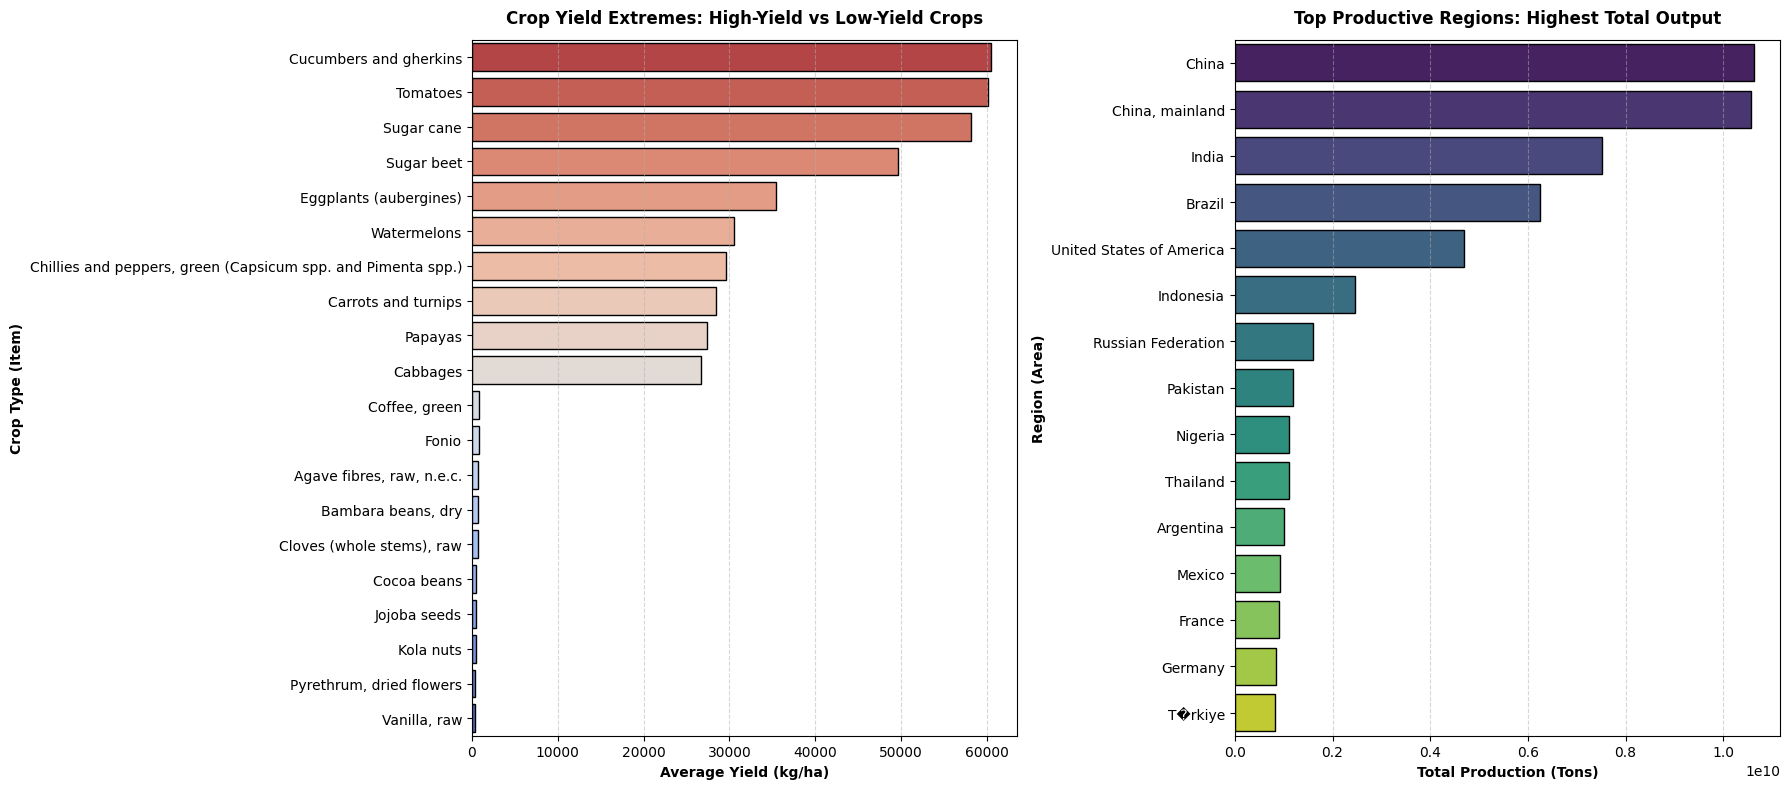

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PART 1: Data Aggregation ---
# 🌾 1. Group by Crop (Item) to find highest vs lowest average yields
crop_yields = final_table.groupby('Item')['Yield_kg_ha'].mean().reset_index()
top_crops = crop_yields.nlargest(10, 'Yield_kg_ha')
bottom_crops = crop_yields.nsmallest(10, 'Yield_kg_ha')
combined_crops = pd.concat([top_crops, bottom_crops]).sort_values('Yield_kg_ha', ascending=False)

# 🗺️ 2. Group by Region (Area) to find most productive regions by total production
region_production = final_table.groupby('Area')['Production_tons'].sum().reset_index()
top_regions = region_production.nlargest(15, 'Production_tons') # Top 15 highly productive areas

# --- PART 2: Visualizations Layout ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 📊 Plot 1: Yield Comparison Across Crops (High vs Low)
sns.barplot(
    data=combined_crops,
    x='Yield_kg_ha',
    y='Item',
    palette='coolwarm_r', # Red for high yield, blue for low yield
    edgecolor='black',
    ax=ax1
)
ax1.set_title('Crop Yield Extremes: High-Yield vs Low-Yield Crops', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Average Yield (kg/ha)', fontweight='bold')
ax1.set_ylabel('Crop Type (Item)', fontweight='bold')
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# 📊 Plot 2: Production Comparison Across Regions
sns.barplot(
    data=top_regions,
    x='Production_tons',
    y='Area',
    palette='viridis', # Beautiful graduation for scaling volumes
    edgecolor='black',
    ax=ax2
)
ax2.set_title('Top Productive Regions: Highest Total Output', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Total Production (Tons)', fontweight='bold')
ax2.set_ylabel('Region (Area)', fontweight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Productivity Analysis
# Examine variations in Yield to identify efficient crops and regions.
# Calculate productivity ratios: Production/Area harvested to cross-verify yields.


/home/dell/Documents/project_3/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/tmp/ipykernel_6132/2732017756.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_6132/2732017756.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Cross-Verification Correlation: nan
💡 (A correlation of 1.00 means your calculated ratio perfectly mirrors the recorded yield columns!)



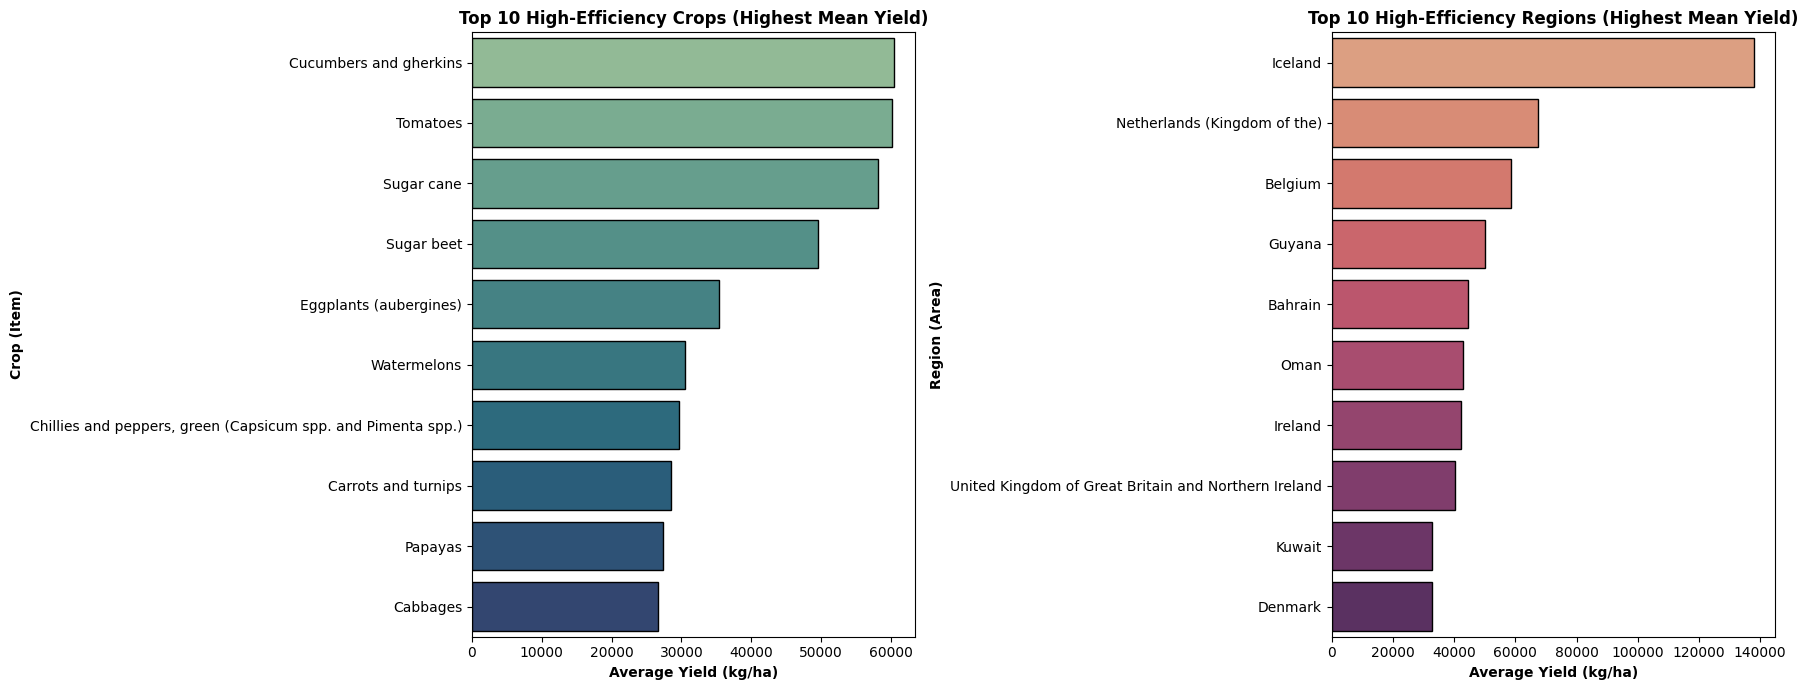

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- STEP 1: Calculate Productivity Ratios & Cross-Verify ---
# Note: Production is usually in tons and Area in hectares. 
# Let's compute the raw ratio: Tons per Hectare
final_table['Calculated_Yield_t_ha'] = final_table['Production_tons'] / final_table['Area_Harvested_ha']

# Check the mathematical correlation between your dataset's Yield and our calculated ratio
verification_corr = final_table['Yield_kg_ha'].corr(final_table['Calculated_Yield_t_ha'])
print(f"📊 Cross-Verification Correlation: {verification_corr:.4f}")
print("💡 (A correlation of 1.00 means your calculated ratio perfectly mirrors the recorded yield columns!)\n")


# --- STEP 2: Identify Efficient Crops and Regions (Top 10 High-Efficiency) ---
# Grouping by Crop to see mean yield and its variance (Standard Deviation)
crop_efficiency = final_table.groupby('Item')['Yield_kg_ha'].agg(['mean', 'std']).reset_index()
top_efficient_crops = crop_efficiency.nlargest(10, 'mean')

# Grouping by Region to see which areas squeeze the most out of their land
region_efficiency = final_table.groupby('Area')['Yield_kg_ha'].agg(['mean', 'std']).reset_index()
top_efficient_regions = region_efficiency.nlargest(10, 'mean')


# --- STEP 3: Plot the Efficiency Variations ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Efficient Crops (Showing mean efficiency + variation markers)
sns.barplot(
    data=top_efficient_crops,
    x='mean',
    y='Item',
    palette='crest',
    edgecolor='black',
    ax=ax1
)
ax1.set_title('Top 10 High-Efficiency Crops (Highest Mean Yield)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Average Yield (kg/ha)', fontweight='bold')
ax1.set_ylabel('Crop (Item)', fontweight='bold')

# Plot B: Efficient Regions (Where land is utilized best)
sns.barplot(
    data=top_efficient_regions,
    x='mean',
    y='Area',
    palette='flare',
    edgecolor='black',
    ax=ax2
)
ax2.set_title('Top 10 High-Efficiency Regions (Highest Mean Yield)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Average Yield (kg/ha)', fontweight='bold')
ax2.set_ylabel('Region (Area)', fontweight='bold')

plt.tight_layout()
plt.show()

In [63]:
# Outliers and Anomalies
# Identify anomalies in Yield or Production, such as unusually high or low values, and correlate them with potential external factors like policies or environmental changes.


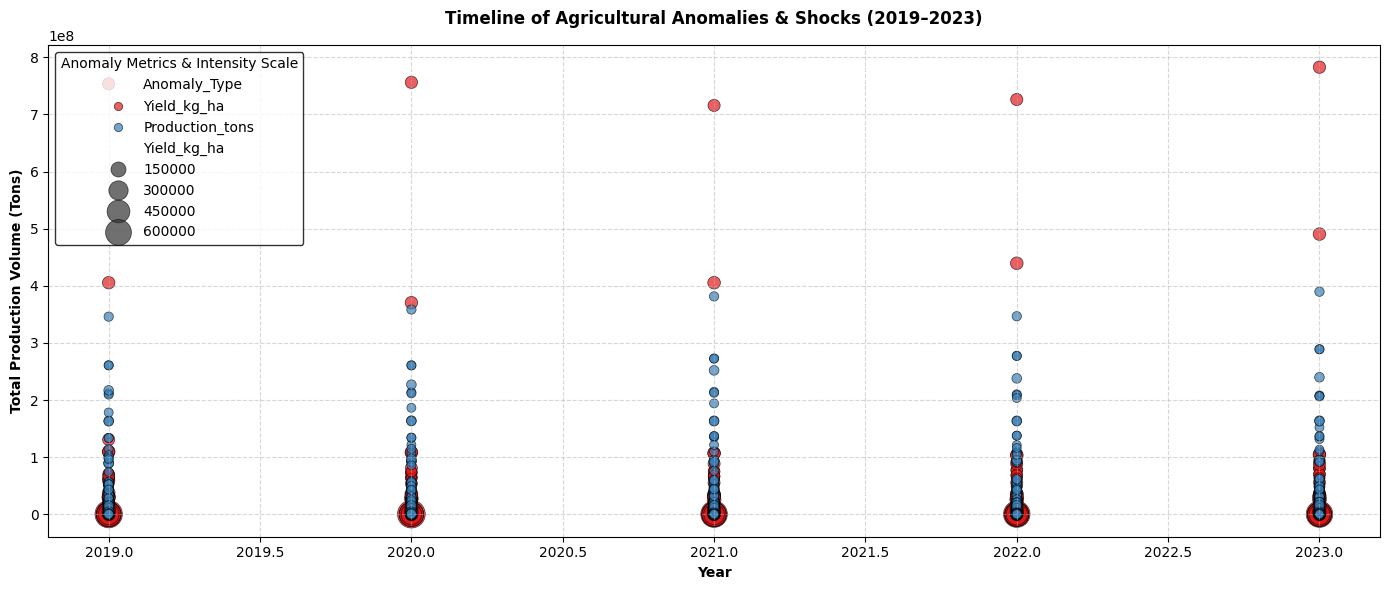

📋 TOP DETECTED ANOMALIES FOR POLICY/ENVIRONMENTAL CORRELATION:
 Year                     Area         Item  Area_Harvested_ha  Yield_kg_ha  Production_tons
 2023                   Brazil   Sugar cane         10065599.0      77748.6      782585836.0
 2020                   Brazil   Sugar cane          9996134.0      75636.3      756070576.0
 2019                   Brazil   Sugar cane         10092430.0      74657.0      753470465.0
 2022                   Brazil   Sugar cane          9886621.0      73437.9      726052712.0
 2021                   Brazil   Sugar cane          9971370.0      71773.4      715679276.0
 2023                    India   Sugar cane          5885317.0      83348.7      490533351.1
 2022                    India   Sugar cane          5175410.0      84906.3      439424890.0
 2019                    India   Sugar cane          5061090.0      80104.5      405416180.0
 2021                    India   Sugar cane          4851230.0      83566.2      405398710.0
 2023 U

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- STEP 1: Mathematical Outlier Detection (Using IQR Method) ---
anomalies_list = []

for metric in ['Yield_kg_ha', 'Production_tons']:
    Q1 = final_table[metric].quantile(0.25)
    Q3 = final_table[metric].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define thresholds for extreme outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter rows that qualify as anomalies
    metric_anomalies = final_table[(final_table[metric] < lower_bound) | (final_table[metric] > upper_bound)].copy()
    metric_anomalies['Anomaly_Type'] = metric
    anomalies_list.append(metric_anomalies)

# Combine detected anomalies into a single dataframe
all_anomalies = pd.concat(anomalies_list).drop_duplicates(subset=['Year', 'Area', 'Item'])

# Let's look at the top 15 most extreme production anomalies to investigate
top_extremes = all_anomalies.nlargest(15, 'Production_tons')


# --- STEP 2: Visualize the Timeline of Anomalies ---
plt.figure(figsize=(14, 6))

# Swarm or Scatter plot to see which years experienced the most volatile shocks
sns.scatterplot(
    data=all_anomalies,
    x='Year',
    y='Production_tons',
    hue='Anomaly_Type',
    size='Yield_kg_ha',
    sizes=(40, 400),
    palette='Set1',
    alpha=0.7,
    edgecolor='black'
)

plt.title('Timeline of Agricultural Anomalies & Shocks (2019–2023)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Total Production Volume (Tons)', fontweight='bold')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(title='Anomaly Metrics & Intensity Scale', frameon=True, edgecolor='black')

plt.tight_layout()
plt.show()

# Print the extreme anomaly ledger for external correlation analysis
print("📋 TOP DETECTED ANOMALIES FOR POLICY/ENVIRONMENTAL CORRELATION:")
print(top_extremes[['Year', 'Area', 'Item', 'Area_Harvested_ha', 'Yield_kg_ha', 'Production_tons']].to_string(index=False))

In [66]:
final_table.to_csv('final_table.csv')

In [67]:
final_table.isna().sum()

Area                         0
Item                         0
Year                         0
Area_Harvested_ha        37525
Yield_kg_ha              40446
Production_tons           3531
Calculated_Yield_t_ha    40349
dtype: int64